# Modelo Random Forest Regressor
En este notebook implementamos **Random Forest Regressor**.
A diferencia de ARIMA, este modelo no mira la serie temporal como única fuente de verdad, sino utiliza otras variables con características específicas.
Se espera que capture mejores resultados que el modelo ARIMA.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf
import os
import joblib

# [DOC] Realizamos la carga de datos y la separación de X (características) e y (objetivo)

df_train = pd.read_csv('../../data/processed/train_data.csv')
df_test = pd.read_csv('../../data/processed/test_data.csv')

X_train = df_train.drop(columns=['Date', 'Sales'])
y_train = df_train['Sales']

X_test = df_test.drop(columns=['Date', 'Sales'])
y_test = df_test['Sales']


In [2]:
# [DOC] Realizamos el entrenamiento del modelo. usamos n_estimators=100 para un buen equilibrio entre velocidad y precisión. 
# También obtenemos medidas que nos serviran para las visualizaciones

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

tree_predictions = np.array([tree.predict(X_test.values) for tree in model.estimators_])

# La media de los árboles es nuestra predicción final
tree_mean = np.mean(tree_predictions, axis=0)

# La desviación estándar entre árboles nos da la "incertidumbre" del modelo
standard_deviation = np.std(tree_predictions, axis=0)

# Definimos un intervalo de confianza (ej. 2 desviaciones estándar)
lower_limit = tree_mean - (2 * standard_deviation)
upper_limit = tree_mean + (2 * standard_deviation)

print(f"[INFO] Modelo Random Forest entrenado con {X_train.shape[1]} variables.")

[INFO] Modelo Random Forest entrenado con 13 variables.


In [3]:
# [DOC] Procedemos a realizar las predicciones necesarias y las métricas necesarias

predictions = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)

mask = y_test != 0
mape = np.mean(np.abs((y_test[mask] - predictions[mask]) / y_test[mask])) * 100

print(f"--- RESULTADOS FINALES ---")
print(f"RMSE: {rmse:.2f} (Castiga errores grandes)")
print(f"MAE:  {mae:.2f} (Error medio en Euros)")
print(f"MAPE: {mape:.2f}% (Error relativo porcentual)")
print(f"--------------------------")

--- RESULTADOS FINALES ---
RMSE: 7116.14 (Castiga errores grandes)
MAE:  5514.04 (Error medio en Euros)
MAPE: 15.36% (Error relativo porcentual)
--------------------------


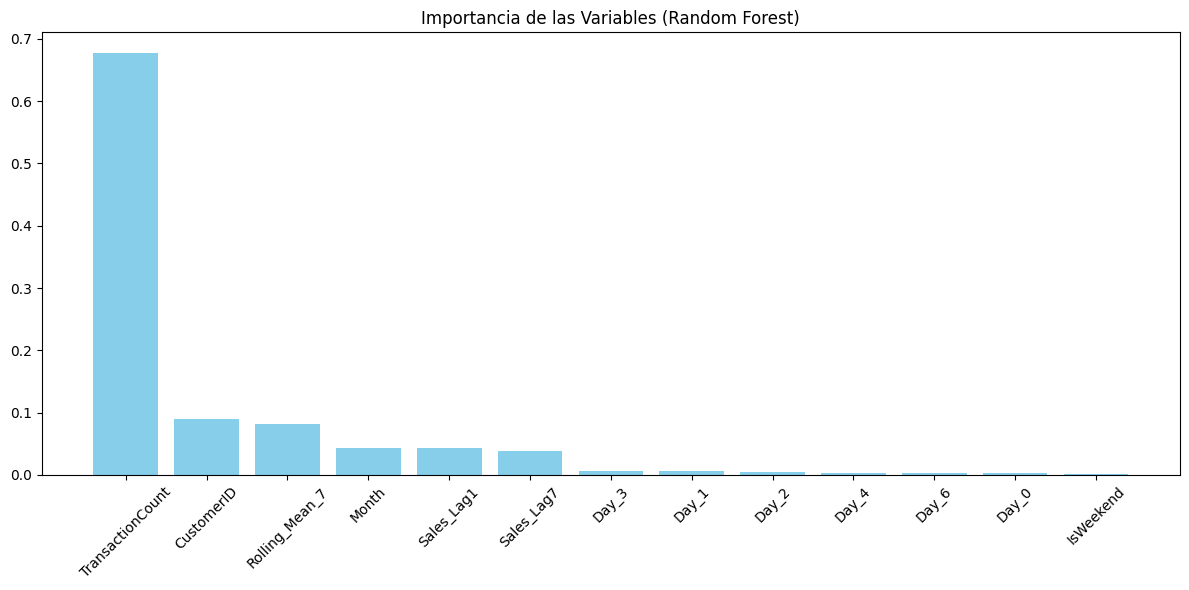

In [4]:
# [DOC] Generamos una gráfica donde extraemos la importancia de las variables

importances = model.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Importancia de las Variables (Random Forest)")
plt.bar(range(X_train.shape[1]), importances[indices], align="center", color='skyblue')
plt.xticks(range(X_train.shape[1]), [feature_names[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

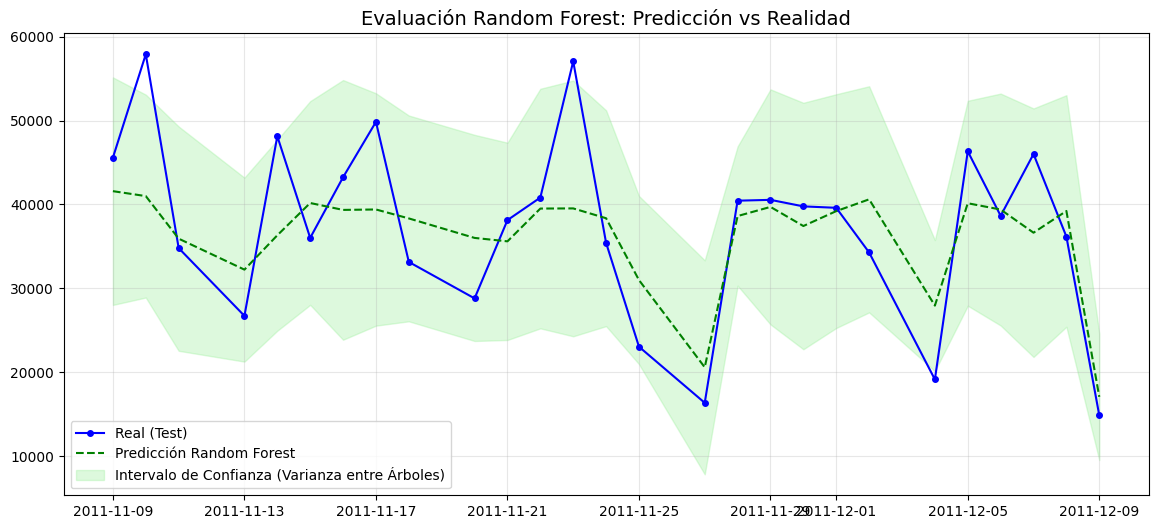

In [5]:
# [DOC] Gráfica de Realidad vs Predicción + Incertidumbre

plt.figure(figsize=(14, 6))

dates = pd.to_datetime(df_test['Date'])

plt.plot(dates, y_test.values, label='Real (Test)', color='blue', marker='o', markersize=4)
plt.plot(dates, tree_mean, label='Predicción Random Forest', color='green', linestyle='--')

plt.fill_between(dates, lower_limit, upper_limit, color='lightgreen', alpha=0.3, label='Intervalo de Confianza (Varianza entre Árboles)')

plt.title('Evaluación Random Forest: Predicción vs Realidad', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

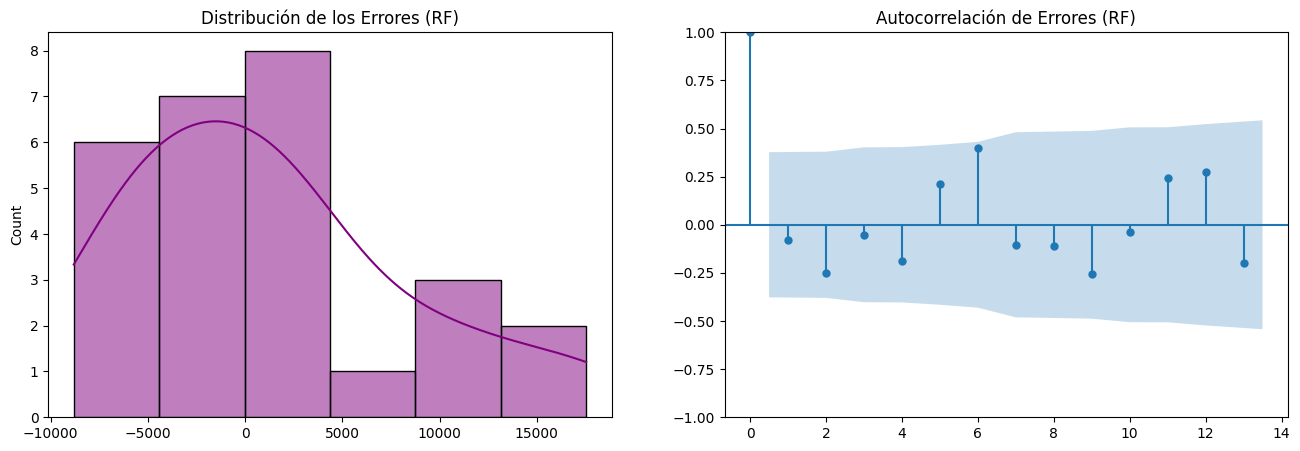

In [6]:
# [DOC] Análisis de Residuos (Errores). Si el modelo es bueno, los errores deben ser aleatorios

residuals = y_test.values - tree_mean

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(residuals, kde=True, ax=ax[0], color='purple')
ax[0].set_title('Distribución de los Errores (RF)')
plot_acf(residuals, ax=ax[1])
ax[1].set_title('Autocorrelación de Errores (RF)')

plt.show()

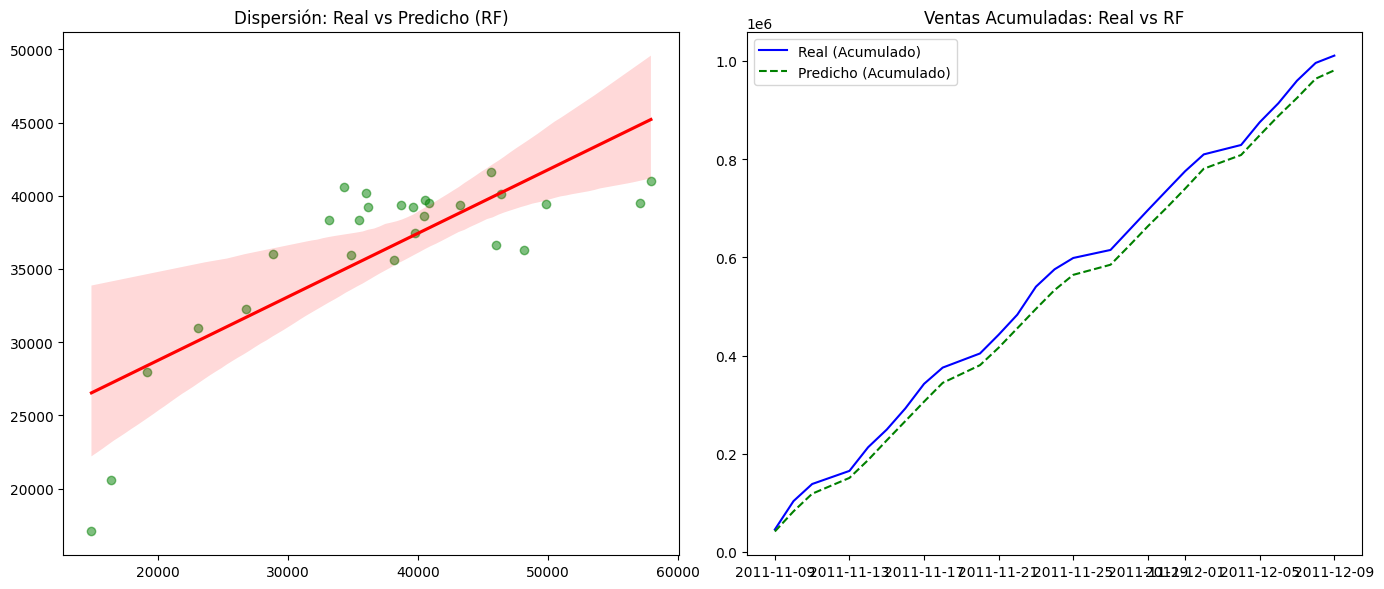

In [7]:
# [DOC] Añadimos otras dos visualicaciones mas comparativas entre lo real y lo predecido

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.regplot(x=y_test.values, y=tree_mean, scatter_kws={'alpha':0.5, 'color':'green'}, line_kws={'color':'red'})
plt.title('Dispersión: Real vs Predicho (RF)')

plt.subplot(1, 2, 2)
plt.plot(dates, y_test.values.cumsum(), label='Real (Acumulado)', color='blue')
plt.plot(dates, tree_mean.cumsum(), label='Predicho (Acumulado)', color='green', linestyle='--')
plt.title('Ventas Acumuladas: Real vs RF')
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
# [DOC] Procedemos a guardar el modelo

model_dir = '../../models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, 'random_forest_v1.pkl')
joblib.dump(model, model_path)
print(f"[SUCCESS] Modelo guardado en: {model_path}")

[SUCCESS] Modelo guardado en: ../../models\random_forest_v1.pkl
